In [1]:
import pandas as pd
import numpy as np

# Load returns (same file you used before)
df = pd.read_csv("../data/processed/dax_log_returns.csv", parse_dates=["Date"], index_col="Date")

# If your column name is different, we’ll fix it after you run this
print(df.columns)
df.head()

Index(['^GDAXI'], dtype='str')


,^GDAXI
Date,
2014-01-03,0.372817
2014-01-06,-0.075813
2014-01-07,0.826025
2014-01-08,-0.087985
2014-01-09,-0.805836


In [2]:
# Define returns series
ret = df['^GDAXI']

ret.head()

Date
2014-01-03    0.372817
2014-01-06   -0.075813
2014-01-07    0.826025
2014-01-08   -0.087985
2014-01-09   -0.805836
Name: ^GDAXI, dtype: float64

In [3]:
# Train-test split (80% train, 20% test)
split = int(len(ret) * 0.8)

ret_train = ret[:split]
ret_test = ret[split:]

print("Train size:", len(ret_train))
print("Test size:", len(ret_test))

Train size: 2459
Test size: 615


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

# Clean returns
ret = ret.dropna()

# Train-test split (80/20)
split = int(len(ret) * 0.8)
ret_train = ret.iloc[:split]
ret_test = ret.iloc[split:]

print("Train size:", len(ret_train))
print("Test size:", len(ret_test))

Train size: 2459
Test size: 615


In [6]:
window = len(ret_train)

sigma2_garch = []
sigma2_gjr = []

full = ret.copy()

for i in range(len(ret_test)):
    end = split + i
    start = end - window
    y = full.iloc[start:end]

    # GARCH(1,1)
    m1 = arch_model(y, mean="Zero", vol="GARCH", p=1, q=1)
    r1 = m1.fit(disp="off")
    f1 = r1.forecast(horizon=1, reindex=False)
    sigma2_garch.append(f1.variance.values[-1, 0])

    # GJR-GARCH(1,1)
    m2 = arch_model(y, mean="Zero", vol="GARCH", p=1, o=1, q=1)
    r2 = m2.fit(disp="off")
    f2 = r2.forecast(horizon=1, reindex=False)
    sigma2_gjr.append(f2.variance.values[-1, 0])

print("Rolling done.")

Rolling done.


In [10]:
sigma2_garch = pd.Series(sigma2_garch, index=ret_test.index)
sigma2_gjr = pd.Series(sigma2_gjr, index=ret_test.index)

sigma_garch = np.sqrt(sigma2_garch)
sigma_gjr = np.sqrt(sigma2_gjr)

rv = ret_test.abs()

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def qlike(y_true_var, y_pred_var):
    eps = 1e-12
    y_pred_var = np.maximum(y_pred_var, eps)
    return np.mean(np.log(y_pred_var) + (y_true_var / y_pred_var))

eval_table = pd.DataFrame({
    "RMSE_vol": {
        "GARCH": rmse(rv, sigma_garch),
        "GJR-GARCH": rmse(rv, sigma_gjr)
    },
    "QLIKE_var": {
        "GARCH": qlike(ret_test**2, sigma2_garch),
        "GJR-GARCH": qlike(ret_test**2, sigma2_gjr)
    }
})

eval_table

,RMSE_vol,QLIKE_var
GARCH,0.637183,0.671968
GJR-GARCH,0.617649,0.652260


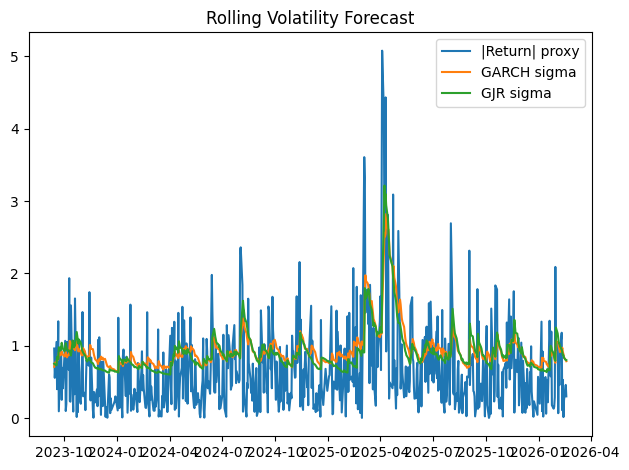

Saved results.


In [9]:
import os
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)

eval_table.to_csv("../results/tables/rolling_forecast_eval.csv")

plt.figure()
plt.plot(rv.index, rv, label="|Return| proxy")
plt.plot(sigma_garch.index, sigma_garch, label="GARCH sigma")
plt.plot(sigma_gjr.index, sigma_gjr, label="GJR sigma")
plt.legend()
plt.title("Rolling Volatility Forecast")
plt.tight_layout()
plt.savefig("../results/figures/rolling_vol_forecast.png", dpi=200)
plt.show()

print("Saved results.")

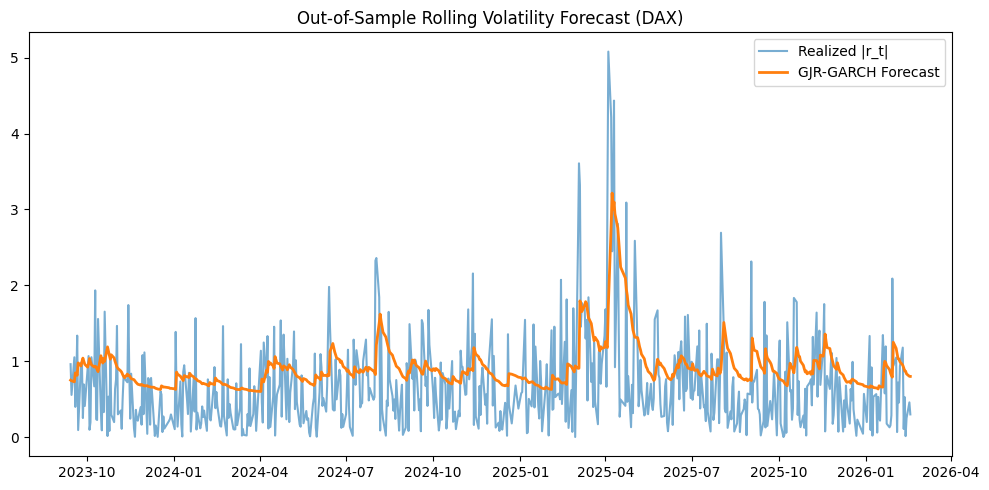

In [11]:
plt.figure(figsize=(10,5))
plt.plot(rv.index, rv, label="Realized |r_t|", alpha=0.6)
plt.plot(sigma_gjr.index, sigma_gjr, label="GJR-GARCH Forecast", linewidth=2)

plt.title("Out-of-Sample Rolling Volatility Forecast (DAX)")
plt.legend()
plt.tight_layout()

plt.savefig("../results/figures/rolling_vol_forecast_clean.png", dpi=300)
plt.show()

In [12]:
best_model = eval_table["QLIKE_var"].idxmin()

summary_text = f"""
Rolling Forecast Summary:
Best model by QLIKE: {best_model}
RMSE comparison:
{eval_table["RMSE_vol"]}
"""

print(summary_text)


Rolling Forecast Summary:
Best model by QLIKE: GJR-GARCH
RMSE comparison:
GARCH        0.637183
GJR-GARCH    0.617649
Name: RMSE_vol, dtype: float64



In [13]:
final_results = pd.DataFrame({
    "realized_abs": rv,
    "garch_sigma": sigma_garch,
    "gjr_sigma": sigma_gjr
})

final_results.to_csv("../results/tables/final_rolling_results.csv")

print("Final rolling results saved.")

Final rolling results saved.
